1- Loding data and calling first 5 rows.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


2 -  Check the shape


In [13]:
df.shape
# I checked the chape to help me in the next steps

(2930, 82)

3 -  Check data type with info().

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

4 - fix 2 wrong type.

In [15]:
# I went back to the course slides to find the correct formula. (page:101,day14)
df['Lot Frontage'] = pd.to_numeric(df['Lot Frontage'], errors='coerce')
df['Garage Cars'] = pd.to_numeric(df['Garage Cars'], errors='coerce')

5 - Find missing value.

In [16]:
pd.set_option('display.max_rows', None) # I found this way to show all missing value from AI.
df.isnull().sum().sort_values(ascending=False)

Pool QC            2917
Misc Feature       2824
Alley              2732
Fence              2358
Mas Vnr Type       1775
Fireplace Qu       1422
Lot Frontage        490
Garage Qual         159
Garage Yr Blt       159
Garage Cond         159
Garage Finish       159
Garage Type         157
Bsmt Exposure        83
BsmtFin Type 2       81
Bsmt Qual            80
Bsmt Cond            80
BsmtFin Type 1       80
Mas Vnr Area         23
Bsmt Full Bath        2
Bsmt Half Bath        2
Total Bsmt SF         1
BsmtFin SF 1          1
BsmtFin SF 2          1
Garage Area           1
Garage Cars           1
Bsmt Unf SF           1
Electrical            1
Lot Shape             0
Street                0
Lot Area              0
MS SubClass           0
MS Zoning             0
Order                 0
PID                   0
House Style           0
Bldg Type             0
Condition 2           0
Condition 1           0
Neighborhood          0
Land Slope            0
Lot Config            0
Utilities       

6 - Drop values that have large missing value.

In [24]:
df = df.drop(columns=["Pool QC","Misc Feature","Alley","Fence"]) # I dropped it because it have a large missing value.

7 - fill in values that don't have large missing value.

In [17]:
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")
df["Fireplace Qu"] = df["Fireplace Qu"].fillna("None")
#-----------------------------------------------------
garage_cols = ["Garage Cond", "Garage Finish", "Garage Type", "Garage Qual"]
for col in garage_cols:
    df[col] = df[col].fillna("None")

bsmt_cols = [ # Numerical + few missing → median(maintains distribution)
    "Bsmt Exposure","BsmtFin Type 2",
    "Bsmt Qual","Bsmt Cond","BsmtFin Type 1"
]
for col in bsmt_cols:
    df[col] = df[col].fillna("None")

# Fill numerical     Numeric feature with moderate missing → median
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median()) 

df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(df["Garage Yr Blt"].median())
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(df["Mas Vnr Area"].median())

num_cols = [
    "BsmtFin SF 1","BsmtFin SF 2","Bsmt Unf SF","Total Bsmt SF",
    "Garage Cars","Garage Area","Bsmt Full Bath","Bsmt Half Bath"
]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill mode
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])


8 - Find duplicates.

In [18]:
df.duplicated().sum() # I didn't find any duplicates, so I didn't fix them.

np.int64(0)

9 - Find outliers using boxplot.

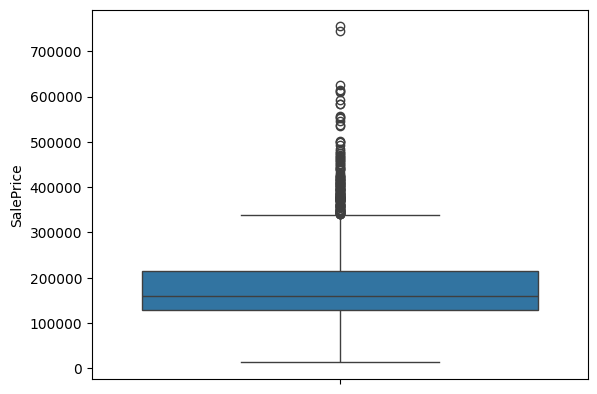

In [19]:
sns.boxplot(y=df["SalePrice"])
plt.show()

10 - Cap extreme values at the 99th percentile.

In [20]:
upper_limit = df["SalePrice"].quantile(0.99)
df["SalePrice"] = df["SalePrice"].clip(upper=upper_limit)
# I clipped the SalePrice at the 99th percentile to minimize the impact of extreme outliers on the model.

11 - Put all steps above to clean_data function.

In [21]:
def clean_data(df):
    # Fix data types
    df['Lot Frontage'] = pd.to_numeric(df['Lot Frontage'], errors='coerce')
    df['Garage Cars'] = pd.to_numeric(df['Garage Cars'], errors='coerce')

    # Drop columns with many missing values
    df = df.drop(columns=["Pool QC","Misc Feature","Alley","Fence"])

    # Fill categorical
    df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")
    df["Fireplace Qu"] = df["Fireplace Qu"].fillna("None")

    garage_cols = ["Garage Cond", "Garage Finish", "Garage Type", "Garage Qu"]
    for col in garage_cols:
        df[col] = df[col].fillna("None")

    bsmt_cols = [
        "Bsmt Exposure","BsmtFin Type 2",
        "Bsmt Qual","Bsmt Cond","BsmtFin Type 1"
    ]
    for col in bsmt_cols:
        df[col] = df[col].fillna("None")

    # Fill numerical
    df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())
    df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(df["Garage Yr Blt"].median())
    df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(df["Mas Vnr Area"].median())

    num_cols = [
        "BsmtFin SF 1","BsmtFin SF 2","Bsmt Unf SF","Total Bsmt SF",
        "Garage Cars","Garage Area","Bsmt Full Bath","Bsmt Half Bath"
    ]
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Fill mode
    df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

    # Remove duplicates
    df = df.drop_duplicates()

    # Handle outliers
    upper_limit = df["SalePrice"].quantile(0.99)
    df["SalePrice"] = df["SalePrice"].clip(upper=upper_limit)

    return df

12 - 3 checks at the end.

In [25]:
assert df.isnull().sum().sum() == 0 # Ensures the dataset is clean.
assert df.shape[0] > 0              # Confirms the dataframe is not empty.
assert df["SalePrice"].min() > 0    # Validates all prices are positive.